# 数据预处理

## 1. 数据清洗
去掉数据中的噪声，纠正不一致

### 1.1 缺失值处理

#### 删除记录、不处理

#### **数据插补**
常见的方式有：
- 均值/中位数/众数插补
- 固定值
- 最近插补：在记录中找到与缺失样本最接近的样本，用该样本的值进行填充
- 回归插补：用其他变量的线性回归来预测缺失值
- 插值法：利用已知点建立适合的插值函数，对缺失值进行插值

#### **插值法**

In [2]:
from scipy import interpolate as itp
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

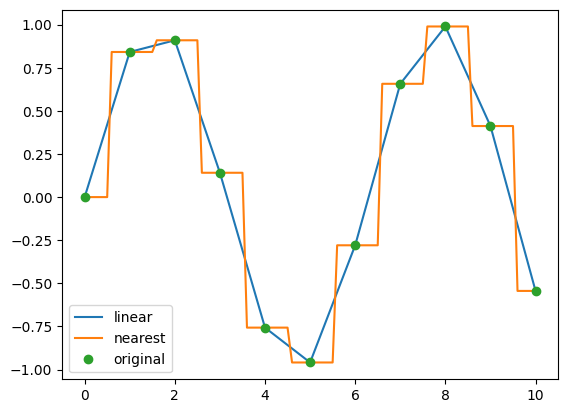

In [3]:
'''
一维插值：interp1d
def __init__(self,
             x: Any,
             y: Any,    len(x) == len(y)
             kind: str = 'linear',
             axis: int = -1,
             copy: bool = True,
             bounds_error: Any = None,
             fill_value: float = np. nan,
             assume_sorted: bool = False) -> 一个函数
kind: 插值类型
    "zero", "nearest": 阶梯插值
    "slinear", "linear": 线性插值
    "quadratic", "cubic": 二次/三次插值，更高阶曲线可以用整数替代
bounds_error: bool, optional
    如果为 True，则当插值点超出范围时会报错，否则会使用 fill_value 进行填充
fill_value: float, optional
    超出范围时使用的填充值
assume_sorted: bool, optional
    如果为 True，则假定输入 x 已经排序，加快插值速度
'''
x = np.linspace(0, 10, 11)
y = np.sin(x)
x_new = np.linspace(0, 10, 101)
kinds = ['linear', 'nearest']
for kind in kinds:
    f = itp.interp1d(x, y, kind=kind)
    y_new = f(x_new)
    plt.plot(x_new, y_new, label=kind)
plt.plot(x, y, 'o', label='original')
plt.legend()
plt.show()

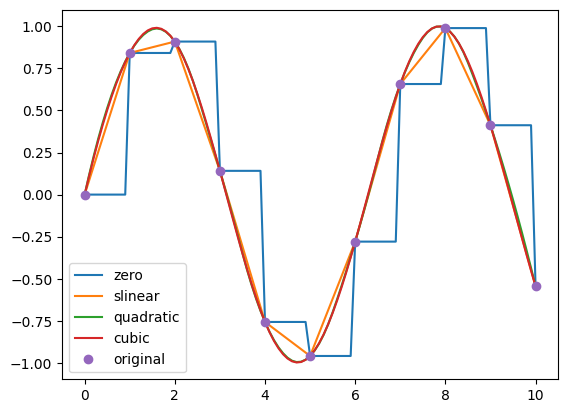

In [4]:
kinds = ['zero', 'slinear', 'quadratic', 'cubic']
for kind in kinds:
    f = itp.interp1d(x, y, kind=kind)
    y_new = f(x_new)
    plt.plot(x_new, y_new, label=kind)
plt.plot(x, y, 'o', label='original')
plt.legend()
plt.show()

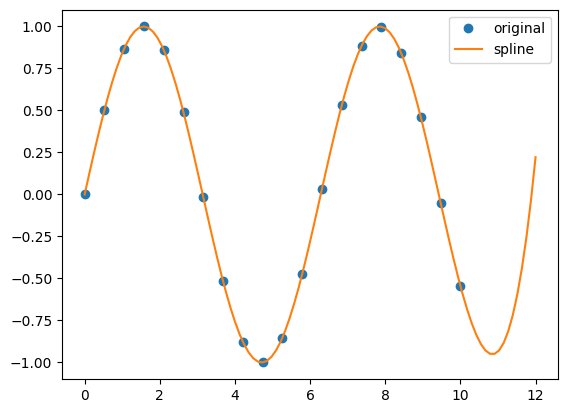

In [5]:
'''
单变量插值：UnivariateSpline
interp1d 不能外推运算，而 UnivariateSpline 可以
def __init__(self, x, y, 
             w=None,            # 每个数据的权重
             bbox=[None]*2,
             k=3,               # 多项式的阶数
             s=None,
                # 平滑度：s=0 时强制通过所有数据点，s>0 时满足 sum(w(y - spline(x))) ** 2 <= s
             ext=0,
             check_finite=False):
'''
x = np.linspace(0, 10, 20)
y = np.sin(x)
f = itp.UnivariateSpline(x, y, s=0)
x_new = np.linspace(0, 12, 100)
y_new = f(x_new)
plt.plot(x, y, 'o', label='original')
plt.plot(x_new, y_new, label='spline')
plt.legend()
plt.show()

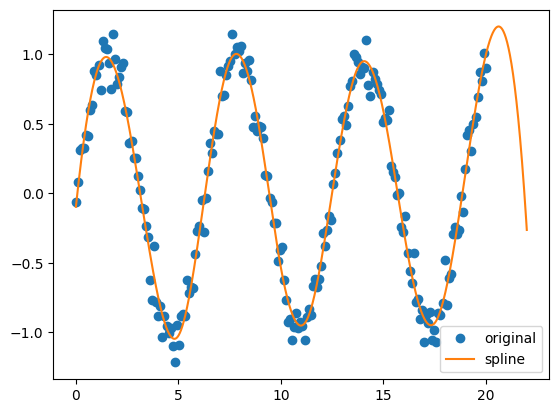

In [6]:
x = np.linspace(0, 20, 200)
y = np.sin(x) + np.random.normal(0, 0.1, 200)
f = itp.UnivariateSpline(x, y, s=2)
x_new = np.linspace(0, 22, 2000)
y_new = f(x_new)
plt.plot(x, y, 'o', label='original')
plt.plot(x_new, y_new, label='spline')
plt.legend()
plt.show()

C:\Users\Ignorant\AppData\Local\Temp\ipykernel_14008\2043943629.py:12: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` instead.
For scattered data, prefer `LinearNDInterpolator` or
`CloughTocher2DInterpolator`.

For more details see
`https://scipy.github.io/devdocs/notebooks/interp_transition_guide.html`

  func = itp.interp2d(x, y, z, kind='cubic')
C:\Users\Ignorant\AppData\Local\Temp\ipykernel_14008\2043943629.py:15: DeprecationWarning: `interp2d` is deprecated in SciPy 1.10 and will be removed in SciPy 1.14.0.

For legacy code, nearly bug-for-bug compatible replacements are
`RectBivariateSpline` on regular grids, and `bisplrep`/`bisplev` for
scattered 2D data.

In new code, for regular grids use `RegularGridInterpolator` ins

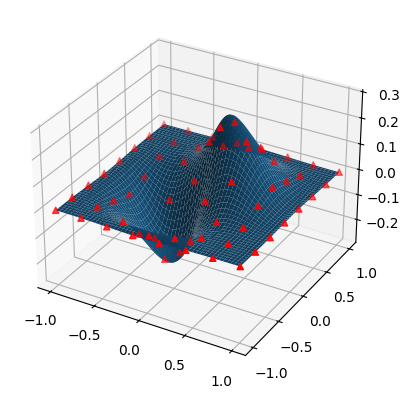

In [7]:
'''
二维插值：interp2d
interp2d(x, y, z, kind='linear', copy=True, bounds_error=False, fill_value=None)
注意事项：
    源数据必须是等距的
    
'''
def f(x, y):
    return (x + y) * np.exp(-5 * (x ** 2 + y ** 2))
x, y = np.mgrid[-1:1:8j, -1:1:8j]
z = f(x, y)
func = itp.interp2d(x, y, z, kind='cubic')
x_new = np.linspace(-1, 1, 100)
y_new = np.linspace(-1, 1, 100)
z_new = func(x_new, y_new)
x_new, y_new = np.mgrid[-1:1:100j, -1:1:100j]

ax = plt.subplot(111, projection='3d')
ax.plot_surface(x_new, y_new, z_new)
ax.scatter(x, y, z, c='r', marker='^')
plt.show()

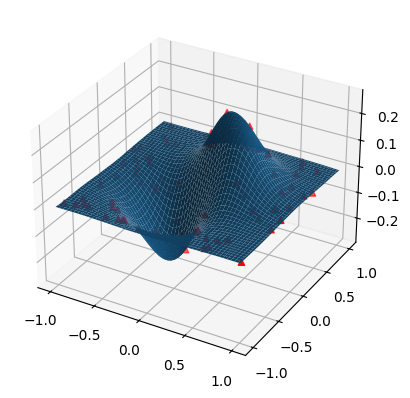

In [8]:
'''
二维插值：Rbf
Rbf 的输入可以是无序的不等间距的网格
'''
x = np.random.uniform(-1, 1, 100)
y = np.random.uniform(-1, 1, 100)
z = f(x, y)
rbf = itp.Rbf(x, y, z, function='multiquadric')
x_new, y_new = np.mgrid[-1:1:100j, -1:1:100j]
z_new = rbf(x_new, y_new)

ax = plt.subplot(111, projection='3d')
ax.plot_surface(x_new, y_new, z_new)
ax.scatter(x, y, z, c='r', marker='^')
plt.show()

### 1.2 异常值处理

#### 1.2.1 直方图
1. 假定数据服从正态分布，根据 3 $\sigma$ 原则检查数据
2. 可以将数据进行标准化，这样只要判断标准化之后的数据是饭否落在 $[-3, 3]$ 之间即可
3. 但是实际场景中数据往往并不服从正态分布，因此该方法应用范围有限

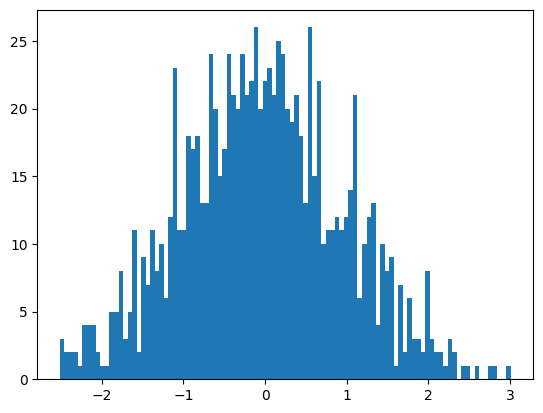

In [9]:
data = np.random.normal(0, 1, 1000)
plt.hist(data, bins=100)
plt.show()

In [10]:
upper_bound = data.mean() + 3 * data.std()
lower_bound = data.mean() - 3 * data.std()
data_normal = data[(data >= lower_bound) & (data <= upper_bound)]
print(len(data_normal))

999


#### 1.2.2 箱型图
1. 箱型图的绘制依靠实际数据，不需要事先假定数据服从特定的分布
2. 箱型图判断异常值的标准以四分位数和四分位差为基础，具有一定抗干扰性
3. 符号定义
    + $Q_1$: 25% 分位数
    + $Q_2$: 50% 分位数（中位数）
    + $Q_3$: 75% 分位数
    + $IQR$: 四分位差，=Q3-Q1
    + 内限: $Q_3+1.5\times IQR\quad Q_1-1.5\times IQR$
    + 外限：$Q_3+3\times IQR\quad Q_1-3\times IQR$
4. 处于内限以外的都是异常值，其中在内限和外限之间异常值称作温和的异常值(mild outliers)；否则称为极端的异常值(extreme outliers)

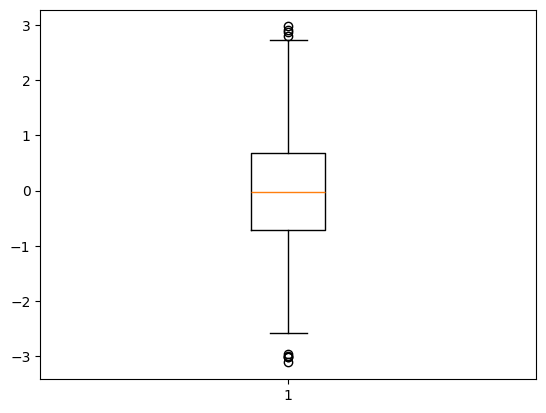

In [11]:
def box_outliers(data, feature, scale=1.5):
    """
    :param data: DataFrame
    :param feature: 需要处理的字段
    :param scale: 删除比例
    :return: 删除异常值后的 DataFrame
    """
    Q1 = data[feature].quantile(0.25)
    Q3 = data[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - scale * IQR
    upper_bound = Q3 + scale * IQR
    return data[(data[feature] >= lower_bound) & (data[feature] <= upper_bound)]

data = pd.DataFrame({'feature': np.random.normal(0, 1, 1000)})
plt.boxplot(data['feature'])
plt.show()

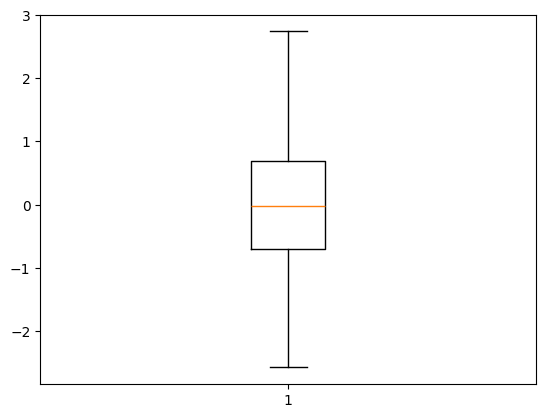

In [12]:
data = box_outliers(data, 'feature')
plt.boxplot(data['feature'])
plt.show()

#### 1.2.3 散点图
1. 箱型图用于分析单个变量或特征中的异常值，当遇到多维的数据，可以使用散点图进行分析
2. 不用箱型图对每个特征单独分析的原因在于，在实际中不同特征之间可能存在相关性（如身高和体重）
3. 具体的处理需要依靠其他离群点的检测和处理算法，如 K-means 聚类、孤立森林 (Isolation Forest) 等，原则是将与其他样本距离超过 d 的样本数超过 p 的样本视为异常值

#### 1.2.4 其他方法
1. 分桶：将数据离散化
2. 数据转换：可以减轻异常值的影响，将一些不好的分布形态转换后可能有所改善

## 2. 数据集成
将多个数据源合并成一致的数据存储，构成一个完整的数据集

## 3. 数据变换
将一种格式的数据转换为另一格式的数据

### 3.1 函数变换
$y=x^2$

$y=\sqrt{x}$

$y=\log(x)$

$\nabla f(x_k)=f(x_{k+1})-f(x_k)$

### 3.2 规范化
将数据按照比例进行缩放，使之落入一个特定的区域，常见的有 $[-1,1]$ 和 $[0,1]$

#### 最大-最小规范化
$x_{norm}=\dfrac{x-\min}{\max-\min}$

#### 零均值规范化
$x_{norm}=\dfrac{x-\mu}{\sigma}$

## 4. 数据规约
通过聚集、删除冗余属性或聚类等方法来压缩数据
### 特征选择
1. 过滤法：按照发散性或相关性对各个特征进行评分，通过设定阈值或者待选择阈的个数来选择特征
2. 包装法：根据目标函数（通常是预测效果评分）每次选择若干特征，或者排除若干特征
3. 嵌入法：使用机器学习的某些算法和模型进行训练，得到特征的权重系数，并根据稀疏从大到小选择特征
4. 主成分分析法：通过降维将多个变量化为少量主成分的多元统计方法。当研究的问题设计多个变量，并且变量间相关性明显，包含的信息有所重叠时，可以考虑使用主成分分析法
5. 用协方差衡量两个变量之间的相关性：$Cov(X,Y)=\dfrac{\sum_{i=1}^n(x_i-\bar{x})(y_i-\bar{y})}{n-1}$
